# Esercizio 1 - Lezione 4
## Modello sequenziale per la regressione

### Caricamento dati

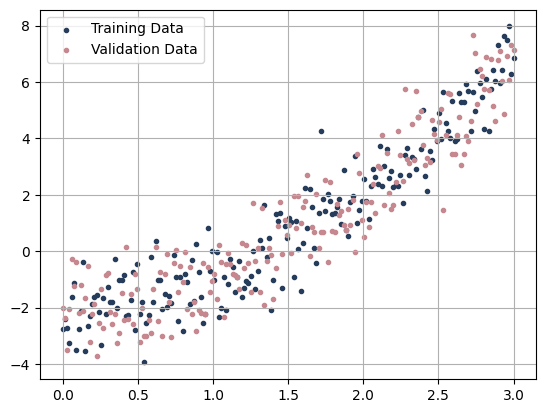

In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat')

x_tr = data[:,0]
y_tr = data[:,1]
x_val = data[:,2]
y_val = data[:,3]

plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Modello lineare di baseline

In [35]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss=tf.keras.losses.MeanSquaredError)

history = model.fit(x_tr, y_tr, epochs=500,
          batch_size = x_tr.shape[0],
          validation_data = (x_val, y_val))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - loss: 4.3836 - val_loss: 4.4632
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.3548 - val_loss: 4.4363
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.3268 - val_loss: 4.4099
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.2993 - val_loss: 4.3840
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.2723 - val_loss: 4.3586
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.2459 - val_loss: 4.3335
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.2198 - val_loss: 4.3088
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.1942 - val_loss: 4.2845
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.1690 - val_loss: 4.2604
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.1441 - val_loss: 4.2366
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.1195 - val_loss: 4.2131
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.0952 - val_l

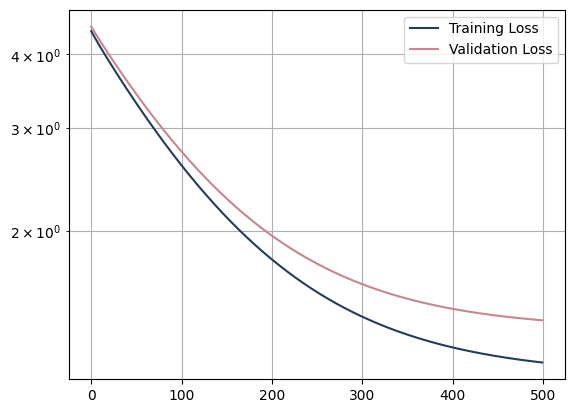

In [36]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


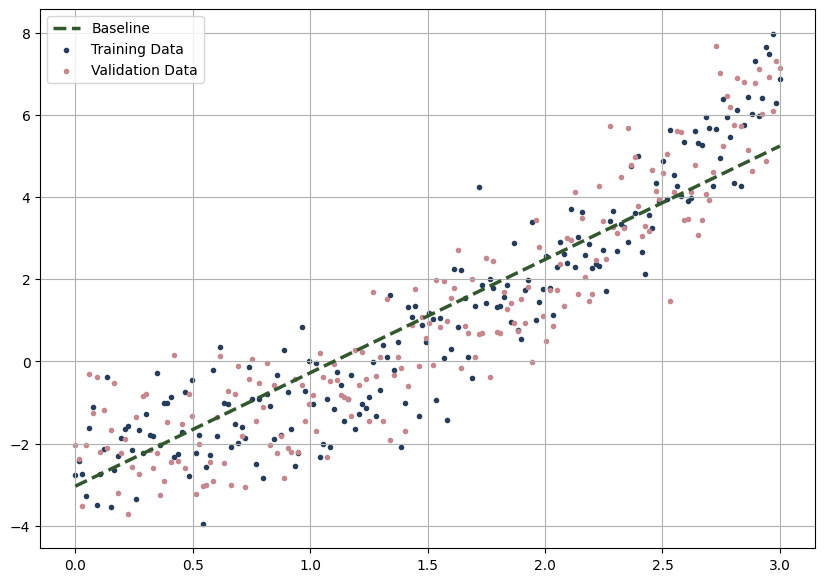

In [37]:
plt.figure(figsize=(10,7))
plt.plot(x_tr, model.predict(x_tr), '--',label='Baseline', color="#31572C", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Fully connected deep neural network con attivazione leaky-relu

In [38]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(1, activation='linear'))

model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss=tf.keras.losses.MSE)

history = model2.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=500, 
                     batch_size=x_tr.shape[0])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - loss: 10.0396 - val_loss: 9.6105
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.6559 - val_loss: 9.2590
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.2982 - val_loss: 8.9221
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8.9552 - val_loss: 8.5883
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.6150 - val_loss: 8.2510
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 8.2709 - val_loss: 7.9057
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 7.9184 - val_loss: 7.5499
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.5545 - val_loss: 7.1837
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.1793 - val_loss: 6.8081
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 6.7937 - val_loss: 6.4355
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 6.4100 - val_loss: 6.0770
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 6.0397 - val_

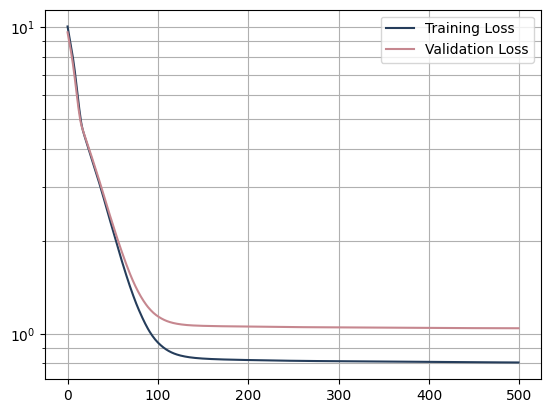

In [39]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


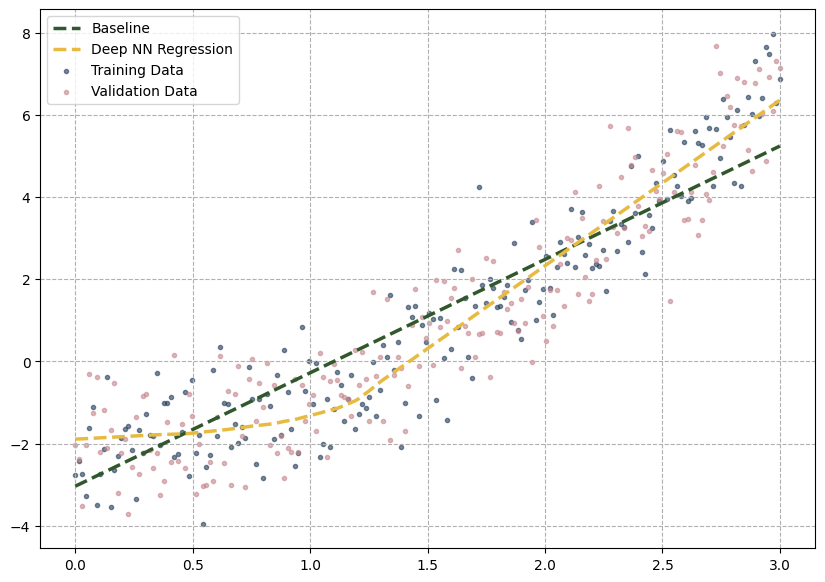

In [40]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model2.predict(x_val), '--', label='Deep NN Regression', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()

### Fully connected deep neural network con relu

In [41]:

model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Input(shape=(1,)))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(10, activation="relu"))
model3.add(tf.keras.layers.Dense(1))
model3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss="mean_squared_error")

history = model3.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=100, 
                     batch_size=x_tr.shape[0])

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - loss: 9.1635 - val_loss: 8.0767
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 8.0935 - val_loss: 7.3488
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 7.3494 - val_loss: 6.7900
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 6.7765 - val_loss: 6.3323
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 6.3057 - val_loss: 6.0326
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 5.9963 - val_loss: 5.7680
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5.7224 - val_loss: 5.5356
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.4808 - val_loss: 5.3328
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.2693 - val_loss: 5.1562
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.0841 - val_loss: 5.0160
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.9367 - val_loss: 4.8853
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7985 - val_l

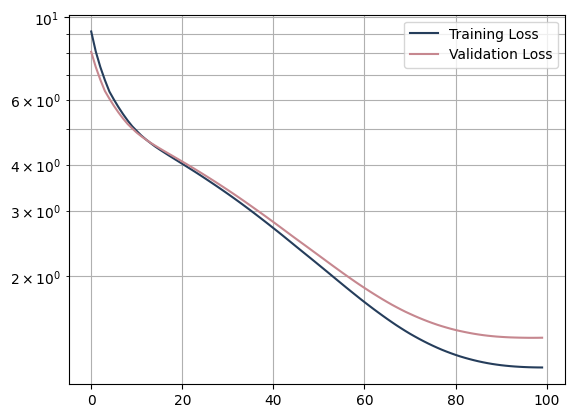

In [42]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


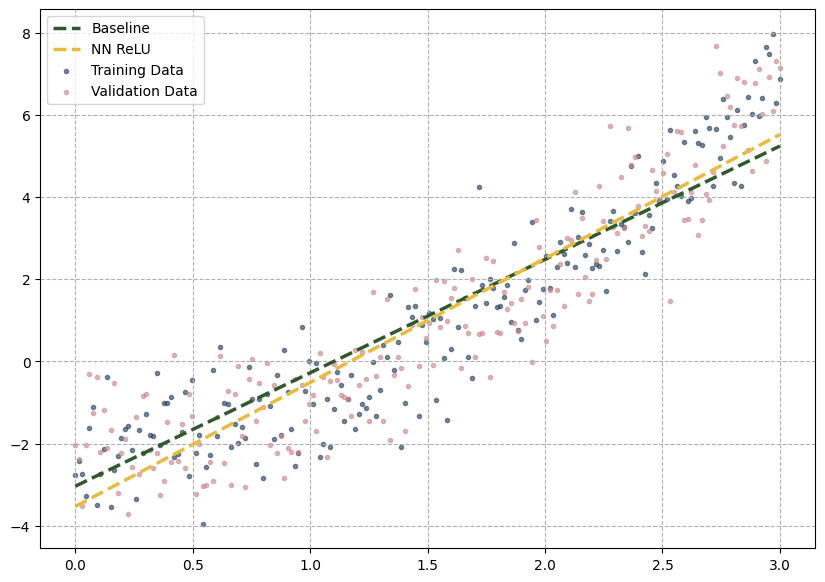

In [43]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model3.predict(x_val), '--', label='NN ReLU', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


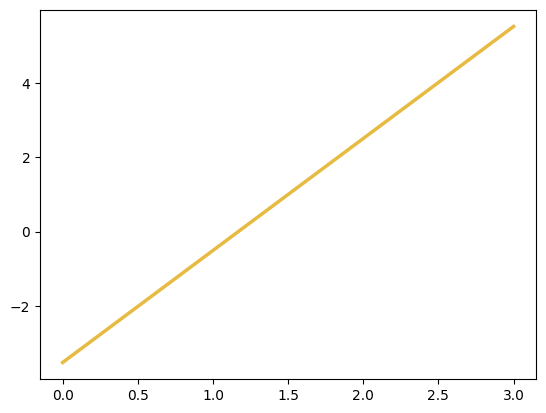

In [44]:
plt.plot(x_val, model3.predict(x_val), label='NN ReLU', color="#E7BB41", linewidth=2.5)
